In [1]:
# ============================================================
# CELL 1 — IMPORTS AND GLOBAL CONFIGURATION
# ============================================================

import os
import time
import json
import random
import pickle
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import pennylane as qml

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("PyTorch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE_DIR = "Data"

TRAIN_PATH = os.path.join(
    BASE_DIR,
    "train_selected.csv"
)

VAL_PATH = os.path.join(
    BASE_DIR,
    "validation_selected.csv"
)

TEST_PATH = os.path.join(
    BASE_DIR,
    "test_selected.csv"
)

OUTPUT_DIR = os.path.join(BASE_DIR, "qnn_optimized")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# QNN configuration
# ------------------------------------------------------------

N_QUBITS = 4
N_LAYERS = 2

# Give the QNN a real training budget
MAX_EPOCHS = 8
PATIENCE = 3

# Training batch size.
# Start with 128. If GPU memory is comfortable, try 256.
BATCH_SIZE = 512

# Validation subset used during training.
# Full validation is only used for final/best evaluation.
VAL_MONITOR_SIZE = 4000

LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nConfiguration")
print("-" * 60)
print("Device:", device)
print("Qubits:", N_QUBITS)
print("Layers:", N_LAYERS)
print("Batch size:", BATCH_SIZE)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Monitor validation size:", VAL_MONITOR_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

PyTorch: 2.5.1+cu121
PennyLane: 0.42.3
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 12.1

Configuration
------------------------------------------------------------
Device: cuda
Qubits: 4
Layers: 2
Batch size: 512
Max epochs: 8
Patience: 3
Monitor validation size: 4000
Learning rate: 0.01
Weight decay: 0.0001


In [2]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nLabel distribution:")
print(train_df["label"].value_counts())

Train: (81977, 17)
Validation: (17567, 17)
Test: (17567, 17)

Train columns:
['gnomad_exome_hom_count', 'vep_impact', 'gnomad_genome_hom_count', 'protein_length', 'Molecular consequence', 'vep_variant_class', 'is_nonsense', 'relative_protein_position', 'vep_protein_position', 'protein_position_valid', 'protein_change_available', 'n_region', 'distance_to_nearest_region', 'vep_transcript_count', 'n_domain', 'n_binding_site', 'label']

Label distribution:
label
1    56249
0    25728
Name: count, dtype: int64


In [3]:
# ============================================================
# CELL 3 — OFFICIAL QNN FEATURES
# ============================================================

QNN_FEATURES = [
    "gnomad_exome_hom_count",
    "vep_impact",
    "gnomad_genome_hom_count",
    "protein_length"
]

TARGET = "label"

print("QNN features:")
for i, feature in enumerate(QNN_FEATURES, start=1):
    print(f"{i}. {feature}")

# Verify everything exists
for feature in QNN_FEATURES:
    assert feature in train_df.columns
    assert feature in val_df.columns
    assert feature in test_df.columns

assert TARGET in train_df.columns
assert TARGET in val_df.columns
assert TARGET in test_df.columns

print("\nAll required columns found.")

QNN features:
1. gnomad_exome_hom_count
2. vep_impact
3. gnomad_genome_hom_count
4. protein_length

All required columns found.


In [4]:
# ============================================================
# CELL 4 — EXTRACT FEATURES AND LABELS
# ============================================================

X_train = train_df[QNN_FEATURES].to_numpy(dtype=np.float32)
y_train = train_df[TARGET].to_numpy(dtype=np.float32)

X_val = val_df[QNN_FEATURES].to_numpy(dtype=np.float32)
y_val = val_df[TARGET].to_numpy(dtype=np.float32)

X_test = test_df[QNN_FEATURES].to_numpy(dtype=np.float32)
y_test = test_df[TARGET].to_numpy(dtype=np.float32)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (81977, 4)
X_val:   (17567, 4)
X_test:  (17567, 4)


In [5]:
# ============================================================
# CELL 5 — QUANTUM INPUT SCALING
# ============================================================

qnn_scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train_q = qnn_scaler.fit_transform(X_train).astype(np.float32)
X_val_q = qnn_scaler.transform(X_val).astype(np.float32)
X_test_q = qnn_scaler.transform(X_test).astype(np.float32)

print("Train range:")
print(X_train_q.min(axis=0))
print(X_train_q.max(axis=0))

print("\nValidation range:")
print(X_val_q.min(axis=0))
print(X_val_q.max(axis=0))

print("\nTest range:")
print(X_test_q.min(axis=0))
print(X_test_q.max(axis=0))

Train range:
[0. 0. 0. 0.]
[3.1415927 3.1415927 3.1415925 3.141593 ]

Validation range:
[0.         0.         0.         0.00064117]
[3.1378405 3.1415927 3.1297958 3.141593 ]

Test range:
[0.         0.         0.         0.00073276]
[3.138206  3.1415927 3.137839  3.141593 ]


In [6]:
# ============================================================
# CELL 6 — TORCH TENSORS
# ============================================================

X_train_tensor = torch.from_numpy(X_train_q)
y_train_tensor = torch.from_numpy(y_train)

X_val_tensor = torch.from_numpy(X_val_q)
y_val_tensor = torch.from_numpy(y_val)

X_test_tensor = torch.from_numpy(X_test_q)
y_test_tensor = torch.from_numpy(y_test)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

print("dtype:", X_train_tensor.dtype)

torch.Size([81977, 4])
torch.Size([81977])
dtype: torch.float32


In [7]:
# ============================================================
# CELL 7 — DATALOADERS
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

# For monitoring, use a FIXED validation subset.
# This prevents the monitored metric from changing due to
# randomly changing validation samples.
monitor_rng = np.random.default_rng(SEED)

monitor_indices = monitor_rng.choice(
    len(X_val_tensor),
    size=min(VAL_MONITOR_SIZE, len(X_val_tensor)),
    replace=False
)

monitor_indices = np.sort(monitor_indices)

X_val_monitor = X_val_tensor[monitor_indices]
y_val_monitor = y_val_tensor[monitor_indices]

val_monitor_dataset = TensorDataset(
    X_val_monitor,
    y_val_monitor
)

pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=pin,
    drop_last=False
)

val_monitor_loader = DataLoader(
    val_monitor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin
)

print("Training batches:", len(train_loader))
print("Monitoring samples:", len(val_monitor_dataset))
print("Monitoring batches:", len(val_monitor_loader))

Training batches: 161
Monitoring samples: 4000
Monitoring batches: 8


In [8]:
# ============================================================
# CELL 8 — VERIFY LIGHTNING GPU
# ============================================================

assert torch.cuda.is_available(), (
    "CUDA is not available. "
    "This QNN experiment is intended to run on GPU."
)

qnn_dev = qml.device(
    "lightning.gpu",
    wires=N_QUBITS
)

print(qnn_dev)
print("Device name:", qnn_dev.name)
print("Wires:", len(qnn_dev.wires))

<lightning.gpu device (wires=4) at 0x7f211c166320>
Device name: lightning.gpu
Wires: 4


In [9]:
# ============================================================
# CELL 9 — QUANTUM CIRCUIT
# ============================================================

@qml.qnode(
    qnn_dev,
    interface="torch",
    diff_method="best"
)
def quantum_circuit(inputs, weights):

    # --------------------------------------------------------
    # Data encoding
    # --------------------------------------------------------

    for i in range(N_QUBITS):
        qml.RY(
            inputs[i],
            wires=i
        )

    # --------------------------------------------------------
    # Variational layers
    # --------------------------------------------------------

    for layer in range(N_LAYERS):

        for i in range(N_QUBITS):

            qml.RY(
                weights[layer, i, 0],
                wires=i
            )

            qml.RZ(
                weights[layer, i, 1],
                wires=i
            )

        # Ring entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(
                wires=[i, i + 1]
            )

        qml.CNOT(
            wires=[N_QUBITS - 1, 0]
        )

    # --------------------------------------------------------
    # Measure ALL qubits
    # --------------------------------------------------------

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(N_QUBITS)
    ]


print("Quantum circuit created.")

Quantum circuit created.


In [10]:
# ============================================================
# CELL 10 — BATCHED HYBRID QNN
# ============================================================

class HybridQNNBatched(nn.Module):

    def __init__(
        self,
        n_qubits=4,
        n_layers=2
    ):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Trainable quantum parameters
        self.weights = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_qubits,
                2,
                dtype=torch.float32
            )
        )

        # Classical readout
        self.classical = nn.Linear(
            n_qubits,
            1
        )

    def forward(self, x):

        # ----------------------------------------------------
        # x shape:
        # [batch, 4]
        # ----------------------------------------------------

        quantum_outputs = quantum_circuit_batched(
            x,
            self.weights
        )

        # PennyLane returns a list of 4 tensors
        #
        # Convert:
        # [tensor(batch), tensor(batch), ...]
        #
        # into:
        # [batch, 4]

        if isinstance(
            quantum_outputs,
            (list, tuple)
        ):

            quantum_outputs = torch.stack(
                quantum_outputs,
                dim=-1
            )

        # ----------------------------------------------------
        # Classical readout
        # ----------------------------------------------------

        logits = self.classical(
            quantum_outputs
        )

        return logits.squeeze(1)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = HybridQNNBatched(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS
).to(device)

print(model)

print("\nParameter shapes:")

for name, param in model.named_parameters():
    print(
        f"{name}: "
        f"{tuple(param.shape)}"
    )

print(
    "\nTotal parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

HybridQNNBatched(
  (classical): Linear(in_features=4, out_features=1, bias=True)
)

Parameter shapes:
weights: (2, 4, 2)
classical.weight: (1, 4)
classical.bias: (1,)

Total parameters: 21


In [11]:
# ============================================================
# CELL 11 — OPTIMIZER
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

print(optimizer)
print(scheduler)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)


In [12]:
# ============================================================
# CELL 12 — FAST VALIDATION FUNCTION
# ============================================================

def evaluate_monitor(model, loader):

    model.eval()

    all_probs = []
    all_targets = []

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            probs = torch.sigmoid(logits)

            batch_size = len(y_batch)

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            all_probs.append(
                probs.detach().cpu().numpy()
            )

            all_targets.append(
                y_batch.detach().cpu().numpy()
            )

    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)

    avg_loss = total_loss / total_samples

    roc = roc_auc_score(
        targets,
        probs
    )

    pr_auc = average_precision_score(
        targets,
        probs
    )

    return {
        "loss": avg_loss,
        "roc_auc": roc,
        "pr_auc": pr_auc
    }

In [13]:
# ============================================================
# CELL 12.5 — BATCHED QUANTUM CIRCUIT
# ============================================================

@qml.qnode(
    qnn_dev,
    interface="torch",
    diff_method="best"
)
def quantum_circuit_batched(inputs, weights):

    # inputs shape: [batch, 4]

    # --------------------------------------------------------
    # Data encoding
    # --------------------------------------------------------

    for i in range(N_QUBITS):
        qml.RY(
            inputs[..., i],
            wires=i
        )

    # --------------------------------------------------------
    # Variational layers
    # --------------------------------------------------------

    for layer in range(N_LAYERS):

        for i in range(N_QUBITS):

            qml.RY(
                weights[layer, i, 0],
                wires=i
            )

            qml.RZ(
                weights[layer, i, 1],
                wires=i
            )

        # Ring entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(
                wires=[i, i + 1]
            )

        qml.CNOT(
            wires=[N_QUBITS - 1, 0]
        )

    # --------------------------------------------------------
    # Measure all four qubits
    # --------------------------------------------------------

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(N_QUBITS)
    ]


print("Batched quantum circuit defined successfully.")

Batched quantum circuit defined successfully.


In [14]:
# ============================================================
# CELL 13 — CORRECT BATCHED FORWARD TEST
# ============================================================

test_batch_size = 512

X_test_batch = X_train_tensor[:test_batch_size].to(
    device,
    non_blocking=True
)

weights_test = (
    0.01 *
    torch.randn(
        N_LAYERS,
        N_QUBITS,
        2,
        device=device,
        dtype=torch.float32,
        requires_grad=True
    )
)

print("Input shape:", X_test_batch.shape)
print("Weights shape:", weights_test.shape)

try:

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    output = quantum_circuit_batched(
        X_test_batch,
        weights_test
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    forward_time = time.perf_counter() - start

    # Convert list of CUDA tensors into a tensor
    if isinstance(output, (list, tuple)):
        output_tensor = torch.stack(output, dim=-1)
    else:
        output_tensor = output

    print("\nSUCCESS")
    print("Output tensor shape:", output_tensor.shape)
    print(
        "Output device:",
        output_tensor.device
    )
    print(
        "Sample output:",
        output_tensor[0].detach().cpu().numpy()
    )
    print(
        f"Forward time: "
        f"{forward_time:.4f} sec"
    )

except Exception as e:

    print("\nBATCHED EXECUTION FAILED")
    print(type(e).__name__)
    print(str(e))

Input shape: torch.Size([512, 4])
Weights shape: torch.Size([2, 4, 2])

SUCCESS
Output tensor shape: torch.Size([512, 4])
Output device: cuda:0
Sample output: [-0.9935592   0.9934251  -0.9936096   0.99959314]
Forward time: 4.8136 sec


In [15]:
# ============================================================
# CELL 13.5 — BATCHED MODEL FORWARD/BACKWARD TEST
# ============================================================

model.train()

X_check = X_train_tensor[:512].to(
    device,
    non_blocking=True
)

y_check = y_train_tensor[:512].to(
    device,
    non_blocking=True
)

optimizer.zero_grad(
    set_to_none=True
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

logits_check = model(X_check)

loss_check = criterion(
    logits_check,
    y_check
)

loss_check.backward()

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start

print("=" * 60)
print("BATCHED MODEL CHECK")
print("=" * 60)

print("Input:", X_check.shape)
print("Output:", logits_check.shape)
print("Loss:", loss_check.item())

print(
    "Quantum gradient norm:",
    model.weights.grad.norm().item()
)

print(
    "Classical gradient norm:",
    model.classical.weight.grad.norm().item()
)

print(
    f"Forward + backward: "
    f"{elapsed:.3f} sec"
)

print(
    f"Samples/sec: "
    f"{512 / elapsed:.2f}"
)

BATCHED MODEL CHECK
Input: torch.Size([512, 4])
Output: torch.Size([512])
Loss: 0.7443522810935974
Quantum gradient norm: 0.0070924293249845505
Classical gradient norm: 0.5393893122673035
Forward + backward: 8.906 sec
Samples/sec: 57.49


In [16]:
# ============================================================
# CELL 14 — OPTIMIZED QNN TRAINING
# ============================================================

history = []

best_val_roc = -np.inf
best_epoch = -1
epochs_without_improvement = 0

best_model_path = os.path.join(
    OUTPUT_DIR,
    "qnn_v2_optimized_best.pt"
)

print("=" * 70)
print("STARTING OPTIMIZED QNN TRAINING")
print("=" * 70)

training_start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.perf_counter()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    n_samples = 0

    for batch_idx, (X_batch, y_batch) in enumerate(
        train_loader,
        start=1
    ):

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        optimizer.step()

        batch_size = len(y_batch)

        running_loss += (
            loss.item() * batch_size
        )

        n_samples += batch_size

    train_loss = running_loss / n_samples

    # ========================================================
    # VALIDATION MONITOR
    # ========================================================

    val_start = time.perf_counter()

    monitor_metrics = evaluate_monitor(
        model,
        val_monitor_loader
    )

    val_time = time.perf_counter() - val_start

    val_loss = monitor_metrics["loss"]
    val_roc = monitor_metrics["roc_auc"]
    val_pr = monitor_metrics["pr_auc"]

    # ========================================================
    # LR scheduler
    # ========================================================

    scheduler.step(val_roc)

    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # Timing
    # ========================================================

    epoch_time = time.perf_counter() - epoch_start

    # ========================================================
    # Save history
    # ========================================================

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_roc_auc": val_roc,
        "val_pr_auc": val_pr,
        "learning_rate": current_lr,
        "epoch_time_sec": epoch_time,
        "validation_time_sec": val_time
    })

    # ========================================================
    # Checkpoint
    # ========================================================

    improved = val_roc > best_val_roc

    if improved:

        best_val_roc = val_roc
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_roc_auc": val_roc,
                "val_pr_auc": val_pr,
                "features": QNN_FEATURES,
                "n_qubits": N_QUBITS,
                "n_layers": N_LAYERS,
                "seed": SEED
            },
            best_model_path
        )

        marker = "  <-- BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    # ========================================================
    # Print
    # ========================================================

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"ROC-AUC: {val_roc:.4f} | "
        f"PR-AUC: {val_pr:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time/60:.2f} min"
        f"{marker}"
    )

    # ========================================================
    # Early stopping
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered "
            f"after {epoch} epochs."
        )

        break

total_training_time = (
    time.perf_counter() - training_start
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Total training time: "
    f"{total_training_time/60:.2f} minutes"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best monitored ROC-AUC: "
    f"{best_val_roc:.6f}"
)

STARTING OPTIMIZED QNN TRAINING
Epoch 01/8 | Train Loss: 0.4446 | Val Loss: 0.3592 | ROC-AUC: 0.8969 | PR-AUC: 0.9582 | LR: 1.00e-02 | Time: 23.26 min  <-- BEST
Epoch 02/8 | Train Loss: 0.3599 | Val Loss: 0.3453 | ROC-AUC: 0.9045 | PR-AUC: 0.9604 | LR: 1.00e-02 | Time: 22.49 min  <-- BEST
Epoch 03/8 | Train Loss: 0.3535 | Val Loss: 0.3402 | ROC-AUC: 0.9049 | PR-AUC: 0.9607 | LR: 1.00e-02 | Time: 22.83 min  <-- BEST
Epoch 04/8 | Train Loss: 0.3497 | Val Loss: 0.3364 | ROC-AUC: 0.9047 | PR-AUC: 0.9596 | LR: 1.00e-02 | Time: 22.47 min
Epoch 05/8 | Train Loss: 0.3465 | Val Loss: 0.3348 | ROC-AUC: 0.9047 | PR-AUC: 0.9608 | LR: 5.00e-03 | Time: 22.47 min
Epoch 06/8 | Train Loss: 0.3448 | Val Loss: 0.3322 | ROC-AUC: 0.9046 | PR-AUC: 0.9608 | LR: 5.00e-03 | Time: 23.87 min

Early stopping triggered after 6 epochs.

TRAINING COMPLETE
Total training time: 137.39 minutes
Best epoch: 3
Best monitored ROC-AUC: 0.904872


In [17]:
# ============================================================
# CELL 15 — SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_path = os.path.join(
    OUTPUT_DIR,
    "qnn_v2_optimized_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(history_df)
print("\nSaved:", history_path)

   epoch  train_loss  val_loss  val_roc_auc  val_pr_auc  learning_rate  \
0      1    0.444593  0.359235     0.896873    0.958168          0.010   
1      2    0.359859  0.345275     0.904479    0.960443          0.010   
2      3    0.353498  0.340206     0.904872    0.960678          0.010   
3      4    0.349652  0.336386     0.904709    0.959593          0.010   
4      5    0.346477  0.334776     0.904732    0.960793          0.005   
5      6    0.344800  0.332182     0.904582    0.960788          0.005   

   epoch_time_sec  validation_time_sec  
0     1395.749215            33.278630  
1     1349.621250            33.162212  
2     1369.690770            34.795307  
3     1348.324992            33.134816  
4     1347.952926            33.072073  
5     1432.270703            37.083854  

Saved: Data/qnn_optimized/qnn_v2_optimized_training_history.csv


In [18]:
# ============================================================
# CELL 16 — LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best checkpoint loaded.")
print("Best epoch:", checkpoint["epoch"])
print("Monitor ROC-AUC:", checkpoint["val_roc_auc"])
print("Monitor PR-AUC:", checkpoint["val_pr_auc"])

Best checkpoint loaded.
Best epoch: 3
Monitor ROC-AUC: 0.9048716307496609
Monitor PR-AUC: 0.9606783430373512


/tmp/ipykernel_104845/3015005889.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


In [19]:
# ============================================================
# CELL 17 — FULL VALIDATION EVALUATION
# ============================================================

full_val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

full_val_loader = DataLoader(
    full_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin
)

model.eval()

all_val_probs = []
all_val_targets = []

validation_start = time.perf_counter()

with torch.no_grad():

    for X_batch, y_batch in full_val_loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        logits = model(X_batch)

        probs = torch.sigmoid(
            logits
        )

        all_val_probs.append(
            probs.cpu().numpy()
        )

        all_val_targets.append(
            y_batch.numpy()
        )

validation_time = (
    time.perf_counter()
    - validation_start
)

y_val_prob_qnn = np.concatenate(
    all_val_probs
)

y_val_true_qnn = np.concatenate(
    all_val_targets
)

y_val_pred_qnn = (
    y_val_prob_qnn >= 0.5
).astype(int)

print(
    f"Full validation time: "
    f"{validation_time/60:.2f} minutes"
)

Full validation time: 2.67 minutes


In [20]:
# ============================================================
# CELL 18 — VALIDATION METRICS
# ============================================================

qnn_val_metrics = {
    "Accuracy": accuracy_score(
        y_val_true_qnn,
        y_val_pred_qnn
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_true_qnn,
        y_val_pred_qnn
    ),

    "Precision": precision_score(
        y_val_true_qnn,
        y_val_pred_qnn
    ),

    "Recall": recall_score(
        y_val_true_qnn,
        y_val_pred_qnn
    ),

    "F1": f1_score(
        y_val_true_qnn,
        y_val_pred_qnn
    ),

    "ROC-AUC": roc_auc_score(
        y_val_true_qnn,
        y_val_prob_qnn
    ),

    "PR-AUC": average_precision_score(
        y_val_true_qnn,
        y_val_prob_qnn
    ),

    "MCC": matthews_corrcoef(
        y_val_true_qnn,
        y_val_pred_qnn
    )
}

qnn_val_metrics_df = pd.DataFrame(
    [qnn_val_metrics]
)

print(
    qnn_val_metrics_df.to_string(
        index=False
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_val_true_qnn,
        y_val_pred_qnn
    )
)

print("\nClassification report:")
print(
    classification_report(
        y_val_true_qnn,
        y_val_pred_qnn,
        digits=4
    )
)

 Accuracy  Balanced Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC      MCC
 0.805032           0.852271   0.987019 0.725402 0.836226 0.900322 0.957889 0.653906

Confusion matrix:
[[5398  115]
 [3310 8744]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.6199    0.9791    0.7592      5513
         1.0     0.9870    0.7254    0.8362     12054

    accuracy                         0.8050     17567
   macro avg     0.8035    0.8523    0.7977     17567
weighted avg     0.8718    0.8050    0.8120     17567



In [21]:
# ============================================================
# CELL 19 — SAVE QNN ARTIFACTS
# ============================================================

scaler_path = os.path.join(
    OUTPUT_DIR,
    "qnn_scaler.pkl"
)

with open(
    scaler_path,
    "wb"
) as f:
    pickle.dump(
        qnn_scaler,
        f
    )

config = {
    "features": QNN_FEATURES,
    "n_qubits": N_QUBITS,
    "n_layers": N_LAYERS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "seed": SEED,
    "best_epoch": int(best_epoch),
    "best_monitor_roc_auc": float(best_val_roc)
}

config_path = os.path.join(
    OUTPUT_DIR,
    "qnn_v2_optimized_config.json"
)

with open(
    config_path,
    "w"
) as f:
    json.dump(
        config,
        f,
        indent=4
    )

metrics_path = os.path.join(
    OUTPUT_DIR,
    "qnn_v2_optimized_validation_metrics.csv"
)

qnn_val_metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Saved:")
print(scaler_path)
print(config_path)
print(metrics_path)
print(best_model_path)

Saved:
Data/qnn_optimized/qnn_scaler.pkl
Data/qnn_optimized/qnn_v2_optimized_config.json
Data/qnn_optimized/qnn_v2_optimized_validation_metrics.csv
Data/qnn_optimized/qnn_v2_optimized_best.pt


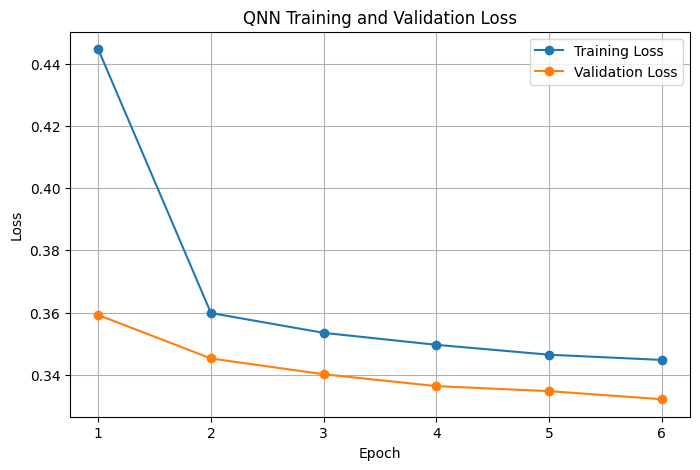

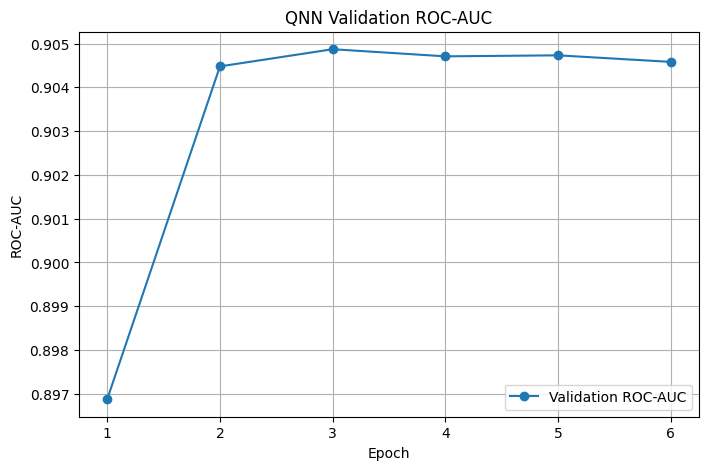

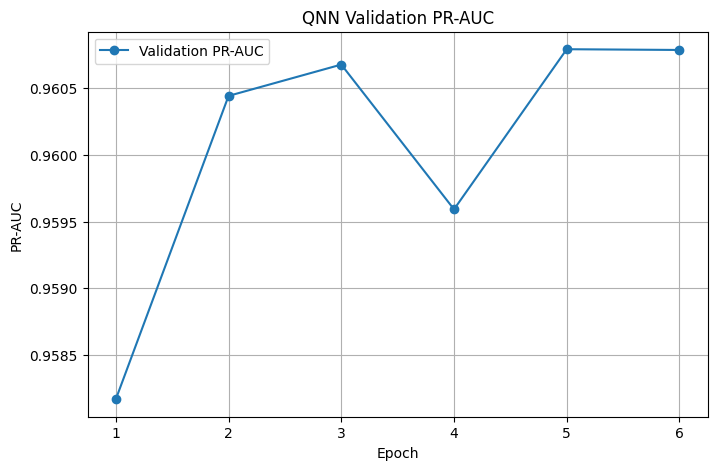

In [22]:
# ============================================================
# CELL 20 — TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("QNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_roc_auc"],
    marker="o",
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("QNN Validation ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("QNN Validation PR-AUC")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# ============================================================
# CELL 21 — FINAL TEST EVALUATION
# DO NOT RUN UNTIL QNN TRAINING IS COMPLETELY FINAL
# ============================================================

# full_test_dataset = TensorDataset(
#     X_test_tensor,
#     y_test_tensor
# )
#
# full_test_loader = DataLoader(
#     full_test_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=pin
# )
#
# model.eval()
#
# all_test_probs = []
# all_test_targets = []
#
# with torch.no_grad():
#
#     for X_batch, y_batch in full_test_loader:
#
#         X_batch = X_batch.to(
#             device,
#             non_blocking=True
#         )
#
#         logits = model(X_batch)
#
#         probs = torch.sigmoid(logits)
#
#         all_test_probs.append(
#             probs.cpu().numpy()
#         )
#
#         all_test_targets.append(
#             y_batch.numpy()
#         )
#
# y_test_prob_qnn = np.concatenate(
#     all_test_probs
# )
#
# y_test_true_qnn = np.concatenate(
#     all_test_targets
# )
#
# y_test_pred_qnn = (
#     y_test_prob_qnn >= 0.5
# ).astype(int)
#
# qnn_test_metrics = {
#     "Accuracy": accuracy_score(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     ),
#
#     "Balanced Accuracy": balanced_accuracy_score(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     ),
#
#     "Precision": precision_score(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     ),
#
#     "Recall": recall_score(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     ),
#
#     "F1": f1_score(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     ),
#
#     "ROC-AUC": roc_auc_score(
#         y_test_true_qnn,
#         y_test_prob_qnn
#     ),
#
#     "PR-AUC": average_precision_score(
#         y_test_true_qnn,
#         y_test_prob_qnn
#     ),
#
#     "MCC": matthews_corrcoef(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     )
# }
#
# print(pd.DataFrame([qnn_test_metrics]))
#
# print("\nConfusion matrix:")
# print(
#     confusion_matrix(
#         y_test_true_qnn,
#         y_test_pred_qnn
#     )
# )

In [24]:
# ============================================================
# QNN IMPLEMENTATION EQUIVALENCE TEST
# ============================================================

model.eval()

# Use one sample
x_single = X_train_tensor[0:1].to(device)

# Use the model's trained quantum weights
test_weights = model.weights.detach().clone()

# ------------------------------------------------------------
# Old circuit — one sample
# ------------------------------------------------------------

old_output = quantum_circuit(
    x_single[0],
    test_weights
)

old_output = torch.stack(
    old_output
)

# ------------------------------------------------------------
# Batched circuit — same sample
# ------------------------------------------------------------

new_output = quantum_circuit_batched(
    x_single,
    test_weights
)

new_output = torch.stack(
    new_output,
    dim=-1
)

new_output = new_output[0]

# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

old_cpu = old_output.detach().cpu().numpy()
new_cpu = new_output.detach().cpu().numpy()

difference = np.abs(
    old_cpu - new_cpu
)

print("=" * 60)
print("QNN IMPLEMENTATION EQUIVALENCE")
print("=" * 60)

print("Old circuit:")
print(old_cpu)

print("\nBatched circuit:")
print(new_cpu)

print("\nAbsolute difference:")
print(difference)

print(
    "\nMaximum difference:",
    difference.max()
)

QNN IMPLEMENTATION EQUIVALENCE
Old circuit:
[-0.9153364   0.74739516 -0.9454181   0.7943595 ]

Batched circuit:
[-0.9153364   0.74739516 -0.9454181   0.7943595 ]

Absolute difference:
[0. 0. 0. 0.]

Maximum difference: 0.0


# FT Transformer


In [28]:
# ============================================================
# FT-TRANSFORMER — SETUP
# ============================================================

import os
import time
import copy
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("FT-TRANSFORMER SETUP")
print("=" * 70)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Speed settings for NVIDIA GPU
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

torch.set_float32_matmul_precision("high")

FT-TRANSFORMER SETUP
PyTorch: 2.5.1+cu121
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [29]:
# ============================================================
# LOAD OFFICIAL MI TOP-4 DATA
# ============================================================

TRAIN_PATH = "Data/train_selected.csv"
VAL_PATH   = "Data/validation_selected.csv"

TARGET = "label"

QNN_FEATURES = [
    "gnomad_exome_hom_count",
    "vep_impact",
    "gnomad_genome_hom_count",
    "protein_length"
]

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)

X_train = train_df[QNN_FEATURES].values.astype(np.float32)
y_train = train_df[TARGET].values.astype(np.float32)

X_val = val_df[QNN_FEATURES].values.astype(np.float32)
y_val = val_df[TARGET].values.astype(np.float32)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nFeatures:")
for i, feature in enumerate(QNN_FEATURES, 1):
    print(f"{i}. {feature}")

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts())

Train shape: (81977, 4)
Validation shape: (17567, 4)

Features:
1. gnomad_exome_hom_count
2. vep_impact
3. gnomad_genome_hom_count
4. protein_length

Train class distribution:
1.0    56249
0.0    25728
Name: count, dtype: int64

Validation class distribution:
1.0    12054
0.0     5513
Name: count, dtype: int64


In [30]:
# ============================================================
# MOVE TRAIN / VALIDATION DATA TO DEVICE
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)

X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)

print("X_train:", X_train_t.shape, X_train_t.device)
print("y_train:", y_train_t.shape, y_train_t.device)

print("X_val:", X_val_t.shape, X_val_t.device)
print("y_val:", y_val_t.shape, y_val_t.device)

X_train: torch.Size([81977, 4]) cuda:0
y_train: torch.Size([81977]) cuda:0
X_val: torch.Size([17567, 4]) cuda:0
y_val: torch.Size([17567]) cuda:0


In [31]:
# ============================================================
# FT-TRANSFORMER
# ============================================================

class NumericalFeatureTokenizer(nn.Module):
    """
    Converts each continuous feature into its own embedding/token.

    Input:
        [batch, n_features]

    Output:
        [batch, n_features, d_token]
    """

    def __init__(self, n_features, d_token):
        super().__init__()

        self.n_features = n_features
        self.d_token = d_token

        self.weight = nn.Parameter(
            torch.randn(n_features, d_token) * 0.02
        )

        self.bias = nn.Parameter(
            torch.zeros(n_features, d_token)
        )

    def forward(self, x):

        # x:
        # [batch, n_features]

        tokens = (
            x.unsqueeze(-1) * self.weight.unsqueeze(0)
            + self.bias.unsqueeze(0)
        )

        # [batch, n_features, d_token]

        return tokens


class FTTransformer(nn.Module):

    def __init__(
        self,
        n_features=4,
        d_token=64,
        n_heads=4,
        n_layers=2,
        d_ff=128,
        dropout=0.1
    ):
        super().__init__()

        self.n_features = n_features
        self.d_token = d_token

        # ----------------------------------------------------
        # Numerical feature embeddings
        # ----------------------------------------------------

        self.tokenizer = NumericalFeatureTokenizer(
            n_features=n_features,
            d_token=d_token
        )

        # ----------------------------------------------------
        # CLS token
        # ----------------------------------------------------

        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, d_token)
        )

        # ----------------------------------------------------
        # Transformer encoder
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.norm = nn.LayerNorm(d_token)

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.head = nn.Linear(d_token, 1)

        # Initialization
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):

        # ----------------------------------------------------
        # Feature tokens
        # ----------------------------------------------------

        tokens = self.tokenizer(x)

        # tokens:
        # [batch, 4, d_token]

        # ----------------------------------------------------
        # Add CLS token
        # ----------------------------------------------------

        batch_size = x.size(0)

        cls = self.cls_token.expand(
            batch_size, -1, -1
        )

        tokens = torch.cat(
            [cls, tokens],
            dim=1
        )

        # [batch, 5, d_token]

        # ----------------------------------------------------
        # Transformer
        # ----------------------------------------------------

        encoded = self.transformer(tokens)

        # ----------------------------------------------------
        # CLS representation
        # ----------------------------------------------------

        cls_output = encoded[:, 0]

        cls_output = self.norm(cls_output)

        # ----------------------------------------------------
        # Binary classification
        # ----------------------------------------------------

        logits = self.head(cls_output)

        return logits.squeeze(1)

In [32]:
# ============================================================
# CREATE FT-TRANSFORMER
# ============================================================

ft_model = FTTransformer(
    n_features=4,
    d_token=64,
    n_heads=4,
    n_layers=2,
    d_ff=128,
    dropout=0.10
).to(DEVICE)

print(ft_model)

# Parameter count
num_params = sum(
    p.numel()
    for p in ft_model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", f"{num_params:,}")

FTTransformer(
  (tokenizer): NumericalFeatureTokenizer()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 67,713


/data/miniconda3/envs/bioinfo/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [33]:
# ============================================================
# FT-TRANSFORMER SANITY CHECK
# ============================================================

ft_model.train()

sample_x = X_train_t[:512]
sample_y = y_train_t[:512]

optimizer = torch.optim.AdamW(
    ft_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.BCEWithLogitsLoss()

start = time.time()

optimizer.zero_grad()

logits = ft_model(sample_x)

loss = criterion(logits, sample_y)

loss.backward()

optimizer.step()

elapsed = time.time() - start

print("Input shape :", sample_x.shape)
print("Output shape:", logits.shape)
print("Loss        :", loss.item())

print("Forward + backward time:",
      f"{elapsed:.3f} sec")

print(
    "Gradient norm:",
    ft_model.head.weight.grad.norm().item()
)

Input shape : torch.Size([512, 4])
Output shape: torch.Size([512])
Loss        : 0.8361490964889526
Forward + backward time: 0.038 sec
Gradient norm: 1.7208642959594727
